In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency

df = pd.read_csv('..\\..\\data\\merged\\merged_final.csv', low_memory=False)

####        Hypothesis 1 
H0: There is no difference in sustainability_score between churned and non-churned customers  
H1: There is a significant difference in sustainability_score between churned and non-churned customers  
Test Type: T-Test

In [4]:
churn = df[df["churn"] == 1]['sustainability_score']
non_churn = df[df["churn"] == 0]['sustainability_score']

t, p = ttest_ind(churn, non_churn, nan_policy='omit')
print("p-value:", p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant difference in sustainability scores between churned and non-churned customers.")
else:    
    print("Fail to reject H0 hypothesis: There is no significant difference in sustainability scores between churned and non-churned customers.")

p-value: 0.0
Reject H0 hypothesis: There is a significant difference in sustainability scores between churned and non-churned customers.


####        Hypothesis 2

H0: Payment amount does not affect churn  
H1: Lower paying customers churn more  
Test Type: T-test

In [5]:
t, p = ttest_ind(
    df[df["churn"]==1]['total_net_paid'],
    df[df["churn"]==0]['total_net_paid'],
    nan_policy='omit'
)
print(p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant difference in total net paid between churned and non-churned customers.")
else:    
    print("Fail to reject H0 hypothesis: There is no significant difference in total net paid between churned and non-churned customers.")

0.0
Reject H0 hypothesis: There is a significant difference in total net paid between churned and non-churned customers.


####        Hypothesis 3

H0: Number of calls has no effect  
H1: Higher number of calls increases churn  
Test Type: T-test

In [6]:
t, p = ttest_ind(
    df[df["churn"]==1]['num_cc_calls'],
    df[df["churn"]==0]['num_cc_calls'],
    nan_policy='omit'
)
print(p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant difference in number of customer care calls between churned and non-churned customers.")
else:    
    print("Fail to reject H0 hypothesis: There is no significant difference in number of customer care calls between churned and non-churned customers.")

0.0
Reject H0 hypothesis: There is a significant difference in number of customer care calls between churned and non-churned customers.


####    Hypothesis 4
H0: Pricing sentiment has no effect  
H1: Negative pricing sentiment increases churn  
Test Type: Chi-square

In [7]:
table = pd.crosstab(df['cc_pricing_sentiment_impact'], df["churn"])
chi2, p, _, _ = chi2_contingency(table)
print(p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant association between customer care pricing sentiment impact and churn.")
else:    
    print("Fail to reject H0 hypothesis: There is no significant association between customer care pricing sentiment impact and churn.")


1.0228950784908112e-19
Reject H0 hypothesis: There is a significant association between customer care pricing sentiment impact and churn.


####        Hypothesis 5 
H0: Payment timeframe does not affect churn  
H1: Customers with delayed payments are more likely to churn  
Test Type: T-test

In [8]:
t, p = ttest_ind(
    df[df['churn']==1]['payment_timeframe'],
    df[df['churn']==0]['payment_timeframe'],
    nan_policy='omit'
)
print(p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant difference in payment timeframe between churned and non-churned customers.")        
else:
    print("Fail to reject H0 hypothesis: There is no significant difference in payment timeframe between churned and non-churned customers.")


9.37955521242486e-189
Reject H0 hypothesis: There is a significant difference in payment timeframe between churned and non-churned customers.


####        Hypothesis 6 
H0: Price switching has no impact on churn  
H1: Customers sensitive to price are more likely to churn  
Test Type: Chi-square

In [9]:
table = pd.crosstab(df['price_switching_flag'], df['churn'])
chi2, p, _, _ = chi2_contingency(table)
print(p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant association between price switching and churn.")   
else:    
    print("Fail to reject H0 hypothesis: There is no significant association between price switching and churn.")

0.2799961590666116
Fail to reject H0 hypothesis: There is no significant association between price switching and churn.


####        Hypothesis 7 
H0: Requesting discount does not affect churn  
H1: Customers asking for discount are more likely to churn  
Test Type: Chi-square

In [10]:
table = pd.crosstab(df['discount_requested_flag'], df['churn'])
chi2, p, _, _ = chi2_contingency(table)
print(p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant association between discount requested and churn.")
else:    
    print("Fail to reject H0 hypothesis: There is no significant association between discount requested and churn.")


9.967882454416942e-05
Reject H0 hypothesis: There is a significant association between discount requested and churn.


####        Hypothesis 8 
H0: Competitor mention has no impact  
H1: Customers mentioning competitors are more likely to churn  
Test Type: Chi-square

In [11]:
table = pd.crosstab(df['competitor_mentioned_flag'], df['churn'])
chi2, p, _, _ = chi2_contingency(table)
print(p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant association between competitor mentioned and churn.")
else:    
    print("Fail to reject H0 hypothesis: There is no significant association between competitor mentioned and churn.")

0.004262385285357113
Reject H0 hypothesis: There is a significant association between competitor mentioned and churn.


####        Hypothesis 9 
H0: Financial hardship has no impact  
H1: Financial hardship increases churn  
Test Type: Chi-square

0.0
Reject H0 hypothesis: There is a significant association between financial hardship mentioned and churn.


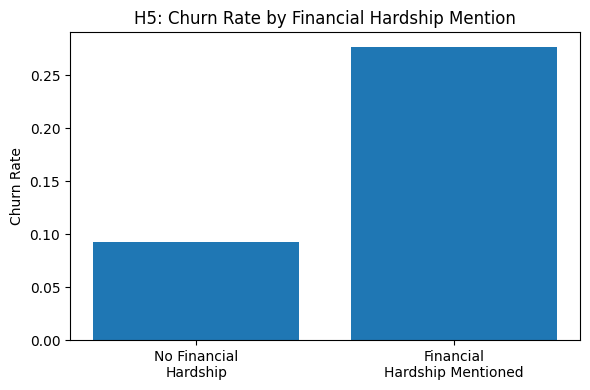

In [12]:
table = pd.crosstab(df['crm_financial_hardship_mentioned'], df['churn'])
chi2, p, _, _ = chi2_contingency(table)
print(p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant association between financial hardship mentioned and churn.")  
else:    
    print("Fail to reject H0 hypothesis: There is no significant association between financial hardship mentioned and churn.")

table = pd.crosstab(df['crm_financial_hardship_mentioned'], df['churn'])
rates = table[1] / table.sum(axis=1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    ['No Financial\nHardship', 'Financial\nHardship Mentioned'],
    rates.values
)

ax.set_title('H5: Churn Rate by Financial Hardship Mention')
ax.set_ylabel('Churn Rate')

plt.tight_layout()
plt.show()

####        Hypothesis 10
H0 : Raising a serious complaint has no effect on churn

H1 : A serious complaint indicates deep dissatisfaction, hence more likely to churn  
Test: Chi-Square  

Chi2_value: 19.52713072016767
P-value: 9.918098475370959e-06
Result: SIGNIFICANT (p < 0.05)
Reject H0: There is a significant association between serious complaint and churn.


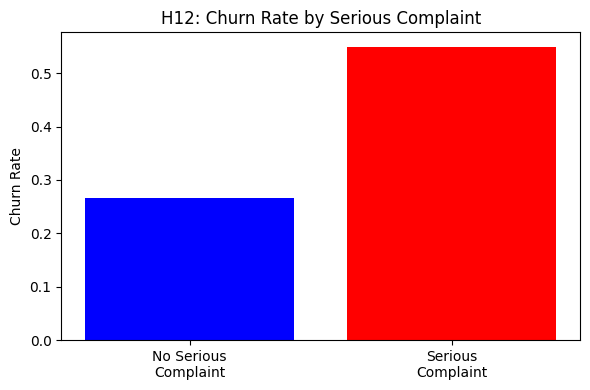

In [15]:
contingency = pd.crosstab(df['serious_complaint_flag'], df['churn'])
chi2, p_value, _, _ = chi2_contingency(contingency)
rates = df.groupby('serious_complaint_flag')['churn'].mean()

print("Chi2_value:", chi2)
print("P-value:", p_value)
if p_value < 0.05:
    print('Result: SIGNIFICANT (p < 0.05)')
    print("Reject H0: There is a significant association between serious complaint and churn.")
else:
    print('Result: NOT SIGNIFICANT (p >= 0.05)')
    print("Fail to reject H0: There is no significant association between serious complaint and churn.")    

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['No Serious\nComplaint', 'Serious\nComplaint'],rates.values, color=['blue', 'red'])
ax.set_title('H12: Churn Rate by Serious Complaint')
ax.set_ylabel('Churn Rate')
plt.tight_layout()
plt.show()

####        Hypothesis 11
H0: Sentiment category is independent of churn  
H1: Sentiment category has a significant association with churn  
Test Type: Chi-square

p-value: 4.6915956590790656e-278
Reject H0 hypothesis: There is a significant association between sentiment category and churn.


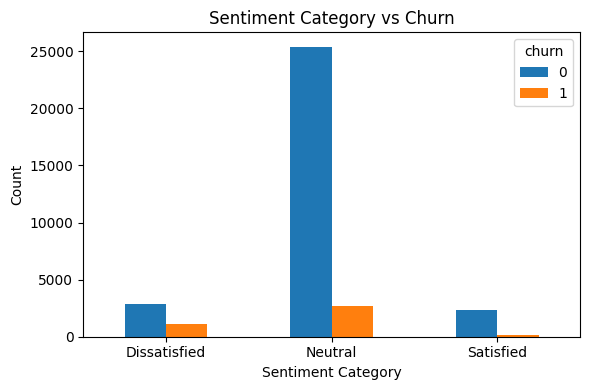

In [16]:
df_sent = df.dropna(subset=['sentiment_category'])
table = pd.crosstab(df_sent['sentiment_category'], df_sent['churn'])
chi2, p, _, _ = chi2_contingency(table)

print("p-value:", p)
if p < 0.05:
    print("Reject H0 hypothesis: There is a significant association between sentiment category and churn.")
else:    
    print("Fail to reject H0 hypothesis: There is no significant association between sentiment category and churn.")

fig, ax = plt.subplots(figsize=(6, 4))
table.plot(kind='bar', ax=ax)

ax.set_title('Sentiment Category vs Churn')
ax.set_xlabel('Sentiment Category')
ax.set_ylabel('Count')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

####        Hypothesis 12

H0 : Audit status has no relationship with whether a customer churns

H1 : A customer whose accreditation audit has Failed or is Suspended no longer provides value to them.
Significantly more likely to leave at renewal.

Test : Chi-Square 


In [17]:

h_data = df[df['proforma_audit_status'].isin([
    'Accredited', 'In Process', 'Failed', 'Suspended'
])].copy()

# Contingency table
contingency = pd.crosstab(h_data['proforma_audit_status'], h_data['churn'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
if p_value < 0.05:
    print("Reject H0 hypothesis: There is a significant association between proforma audit status and churn.")
else:    
    print("Fail to reject H0 hypothesis: There is no significant association between proforma audit status and churn.")

Reject H0 hypothesis: There is a significant association between proforma audit status and churn.



####         Hypothesis 13

H0 :  There is no difference in the average number of client connections
between customers who churn and those who stay.

H1 :  Each client connection is a reason for the customer to keep their
accreditation active. Customers with more connections face a higher switching cost and
are significantly less likely to churn.

Test : T-test 



In [ ]:
churned_conn  = df[df['churn'] == 1]['current_anchorings'].dropna()
retained_conn = df[df['churn'] == 0]['current_anchorings'].dropna()

t_stat, p_value = ttest_ind(churned_conn, retained_conn, equal_var=False)

print(f"Average connections — Churned  : {churned_conn.mean():.2f}")
print(f"Average connections — Retained : {retained_conn.mean():.2f}")
print(f"Difference                     : {retained_conn.mean() - churned_conn.mean():.2f} more connections in retained group")
print()
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.6f}")
print()

if p_value < 0.05:
    print("Reject H0 hypothesis: Retained customers have significantly more client connections than churned customers.")
else:
    print("Fail to reject H0 hypothesis: No significant difference in client connections between groups.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
means = [churned_conn.mean(), retained_conn.mean()]
axes[0].bar(['Churned', 'Retained'], means,
            color=["red", "green"])
for i, v in enumerate(means):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom', fontsize=10)
axes[0].set_title('H13: Mean Client Connections\nChurned vs Retained')
axes[0].set_ylabel('Average Number of Connections')

####        Hypothesis 14

H0 : Suggesting to leave on a customer care call does not affect churn likelihood

H1 : Customers who actively suggest leaving during CC calls churn at a higher rate

Test: Chi-Square 

In [18]:
crosstab_h14 = pd.crosstab(df['cc_contractor_suggest_leave'], df['churn'])
print(crosstab_h14)

chi2_14, p_val_14, dof_14, ex_14 = chi2_contingency(crosstab_h14)

print(f"Chi-Square: {chi2_14:.4f} | P-value: {p_val_14:.4e}")
if p_val_14 < 0.05:
    print("Conclusion: Reject the Null Hypothesis. Threats to leave heavily indicate actual churn.")
else:
    print("Conclusion: Fail to reject. No significant effect found.")

churn                            0      1
cc_contractor_suggest_leave              
0                            33558  12093
1                              447    228
Chi-Square: 17.7240 | P-value: 2.5538e-05
Conclusion: Reject the Null Hypothesis. Threats to leave heavily indicate actual churn.


####        Hypothesis 15

H0 : Process complexity concerns have no relationship with churn.

H1 : Customers frustrated by process complexity are more likely to churn

Test: Chi-Square 


In [19]:
crosstab_h12 = pd.crosstab(df['cc_process_complexity_concerns'], df['churn'])
print(crosstab_h12)

chi2_12, p_val_12, dof_12, ex_12 = chi2_contingency(crosstab_h12)

print(f"Chi-Square: {chi2_12:.4f} | P-value: {p_val_12:.4e}")
if p_val_12 < 0.05:
    print("Conclusion: Reject the Null Hypothesis. Customers with process complexity concerns have significantly different churn rates.")
else:
    print("Conclusion: Fail to reject. No significant effect found.")


churn                               0      1
cc_process_complexity_concerns              
0                               31746  12169
1                                2259    152
Chi-Square: 535.3348 | P-value: 1.9514e-118
Conclusion: Reject the Null Hypothesis. Customers with process complexity concerns have significantly different churn rates.


####    Hypothesis 16

H0 : There is no association between membership band and churn rate.

H1 : Customers on lower membership bands churn at a higher rate than those on higher bands

Test: Chi-Square


P-value:  0.0
Reject H0 hypothesis: There is a significant association between membership band and churn.


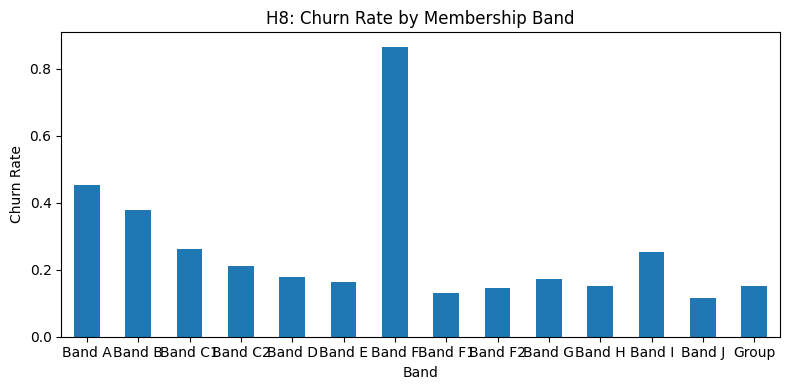

In [20]:
# Filter data
h8_data = df.dropna(subset=['band'])
churn_rates = h8_data.groupby('band')['churn'].mean().sort_values(ascending=False)

# Chi2 test
contingency = pd.crosstab(h8_data['band'], h8_data['churn'])
chi2, p_val, *_ = chi2_contingency(contingency)
print("P-value: ", p_val)

if p_val < 0.05:
    print("Reject H0 hypothesis: There is a significant association between membership band and churn.")
else:    
    print("Fail to reject H0 hypothesis: There is no significant association between membership band and churn.")

# Plot
tg = h8_data.groupby('band')['churn'].mean().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
tg.plot(kind='bar', ax=ax)
ax.set_title('H8: Churn Rate by Membership Band')
ax.set_xlabel('Band')
ax.set_ylabel('Churn Rate')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()